Exploracao inicial de bases publicas para TB-IA

Este notebook baixa pequenas amostras de bases publicas recomendadas para o MVP 1 e organiza os dados no formato que o sistema deve consumir depois.

O foco aqui e visualizacao e validacao inicial, nao ingestao de producao.

Fontes executaveis diretamente neste notebook:

- IBGE Localidades: municipios, UF, regioes.
- IBGE SIDRA/agregados: populacao residente estimada.
- IBGE Malhas: geometria municipal simplificada em GeoJSON.

Fontes DATASUS/CNES/SINAN/SIM tambem podem ser exploradas por download direto de arquivos DBC publicos quando a URL do arquivo for estavel. O notebook baixa algumas amostras pequenas para visualizacao e mantem CSVs manuais como fallback.




## Como rodar

Instale as dependencias exploratorias fora do gate principal do projeto:

```bash
python -m pip install -r requirements-notebook.txt
jupyter lab notebooks/explorar_bases_publicas.ipynb
```

Os dados baixados pelo notebook ficam em `data/raw/` e `data/processed/`, ambos ignorados pelo git.




In [1]:
from __future__ import annotations

import csv
import ftplib
import gzip
import json
from html import unescape
from io import StringIO
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode, urlparse
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

# Detecta se o notebook foi aberto na raiz do repo ou dentro de notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PUBLIC_CACHE_DIR = RAW_DIR / "public_sources"
MANUAL_DIR = RAW_DIR / "manual"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

for directory in [PUBLIC_CACHE_DIR, MANUAL_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

def decode_http_payload(body: bytes, encoding: str | None) -> str:
    """Decodifica respostas JSON que alguns servicos retornam comprimidas."""
    if encoding and "gzip" in encoding.lower():
        body = gzip.decompress(body)
    elif body.startswith(b"\x1f\x8b"):
        body = gzip.decompress(body)
    return body.decode("utf-8")

def fetch_json(url: str, cache_name: str, refresh: bool = False, timeout: int = 60):
    """Baixa JSON com cache simples para evitar chamadas repetidas."""
    cache_path = PUBLIC_CACHE_DIR / cache_name
    if cache_path.exists() and not refresh:
        return json.loads(cache_path.read_text(encoding="utf-8"))

    request = Request(url, headers={"User-Agent": "TB-IA exploratory notebook"})
    with urlopen(request, timeout=timeout) as response:
        payload = decode_http_payload(response.read(), response.headers.get("Content-Encoding"))
    cache_path.write_text(payload, encoding="utf-8")
    return json.loads(payload)

def save_frame(df: pd.DataFrame, name: str) -> Path:
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False)
    print(f"saved: {path.relative_to(PROJECT_ROOT)}")
    return path




In [2]:
# Configuracao inicial: Ceara e municipios de interesse para uma amostra leve.
UF_ID = 23
UF_SIGLA = "CE"
ANO_POPULACAO = 2025

MUNICIPIOS_AMOSTRA = {
    "Fortaleza": "2304400",
    "Caucaia": "2303709",
    "Juazeiro do Norte": "2307304",
    "Maracanau": "2307650",
    "Sobral": "2312908",
}

MUNICIPIO_MAPA_ID = MUNICIPIOS_AMOSTRA["Fortaleza"]




## IBGE Localidades: municipios




In [3]:
# IBGE Localidades: municipios do Ceara.
municipios_url = f"https://servicodados.ibge.gov.br/api/v1/localidades/estados/{UF_ID}/municipios"
municipios_json = fetch_json(municipios_url, f"ibge_municipios_{UF_SIGLA.lower()}.json")

municipios = pd.json_normalize(municipios_json)
municipios_df = municipios.rename(
    columns={
        "id": "municipality_id",
        "nome": "municipality_name",
        "microrregiao.mesorregiao.UF.id": "uf_id",
        "microrregiao.mesorregiao.UF.sigla": "uf_sigla",
        "microrregiao.mesorregiao.UF.nome": "uf_name",
        "microrregiao.mesorregiao.UF.regiao.id": "region_id",
        "microrregiao.mesorregiao.UF.regiao.sigla": "region_sigla",
        "microrregiao.mesorregiao.UF.regiao.nome": "region_name",
    }
)[
    [
        "municipality_id",
        "municipality_name",
        "uf_id",
        "uf_sigla",
        "uf_name",
        "region_id",
        "region_sigla",
        "region_name",
    ]
]
municipios_df["municipality_id"] = municipios_df["municipality_id"].astype(str)
municipios_df.head()




,municipality_id,municipality_name,uf_id,uf_sigla,uf_name,region_id,region_sigla,region_name
0,2300101,Abaiara,23,CE,Ceará,2,NE,Nordeste
1,2300150,Acarape,23,CE,Ceará,2,NE,Nordeste
2,2300200,Acaraú,23,CE,Ceará,2,NE,Nordeste
3,2300309,Acopiara,23,CE,Ceará,2,NE,Nordeste
4,2300408,Aiuaba,23,CE,Ceará,2,NE,Nordeste


## IBGE SIDRA: populacao municipal




In [4]:
# IBGE SIDRA/agregados: populacao residente estimada.
# Agregado 6579, variavel 9324: Populacao residente estimada.
municipality_ids = ",".join(MUNICIPIOS_AMOSTRA.values())
pop_url = (
    "https://servicodados.ibge.gov.br/api/v3/agregados/6579/"
    f"periodos/{ANO_POPULACAO}/variaveis/9324?localidades=N6%5B{municipality_ids}%5D"
)
pop_json = fetch_json(pop_url, f"ibge_populacao_estimada_{ANO_POPULACAO}_{UF_SIGLA.lower()}_amostra.json")

def parse_sidra_population(payload: list[dict], year: int) -> pd.DataFrame:
    rows = []
    for variable in payload:
        for result in variable.get("resultados", []):
            for item in result.get("series", []):
                localidade = item["localidade"]
                rows.append(
                    {
                        "municipality_id": str(localidade["id"]),
                        "municipality_name_sidra": localidade["nome"],
                        "year": year,
                        "population": int(item["serie"][str(year)]),
                        "source": "IBGE SIDRA aggregate 6579 variable 9324",
                    }
                )
    return pd.DataFrame(rows)

population_df = parse_sidra_population(pop_json, ANO_POPULACAO)
population_df = population_df.merge(municipios_df, on="municipality_id", how="left")
population_df = population_df[
    ["municipality_id", "municipality_name", "uf_sigla", "year", "population", "source"]
].sort_values("population", ascending=False)

save_frame(population_df, f"ibge_populacao_amostra_{UF_SIGLA.lower()}_{ANO_POPULACAO}.csv")
population_df




saved: data/processed/ibge_populacao_amostra_ce_2025.csv


,municipality_id,municipality_name,uf_sigla,year,population,source
0,2304400,Fortaleza,CE,2025,2578483,IBGE SIDRA aggregate 6579 variable 9324
1,2303709,Caucaia,CE,2025,378406,IBGE SIDRA aggregate 6579 variable 9324
2,2307304,Juazeiro do Norte,CE,2025,305531,IBGE SIDRA aggregate 6579 variable 9324
3,2307650,Maracanaú,CE,2025,251613,IBGE SIDRA aggregate 6579 variable 9324
4,2312908,Sobral,CE,2025,216519,IBGE SIDRA aggregate 6579 variable 9324


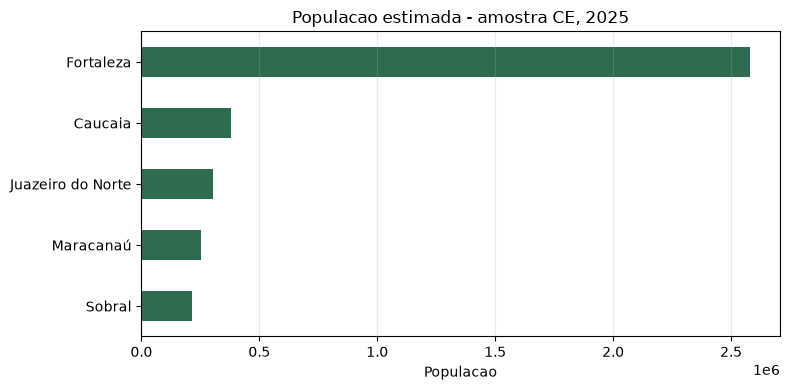

In [5]:
ax = population_df.sort_values("population").plot.barh(
    x="municipality_name",
    y="population",
    figsize=(8, 4),
    legend=False,
    color="#2F6B4F",
)
ax.set_title(f"Populacao estimada - amostra {UF_SIGLA}, {ANO_POPULACAO}")
ax.set_xlabel("Populacao")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()




## IBGE Malhas: geometria para mapas




In [6]:
# IBGE Malhas: geometria municipal simplificada em GeoJSON.
malha_url = (
    "https://servicodados.ibge.gov.br/api/v3/malhas/"
    f"municipios/{MUNICIPIO_MAPA_ID}?formato=application/vnd.geo+json&qualidade=minima"
)
malha_geojson = fetch_json(malha_url, f"ibge_malha_municipio_{MUNICIPIO_MAPA_ID}.geojson")
malha_geojson["features"][0]["properties"]




{'codarea': '2304400'}

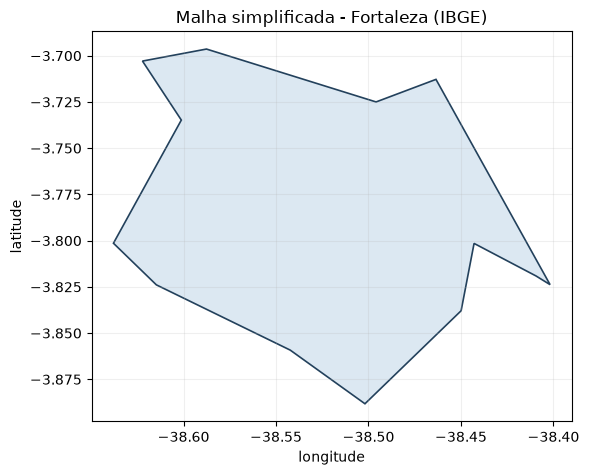

In [7]:
def plot_geojson_feature(feature: dict, title: str) -> None:
    geometry = feature["geometry"]
    if geometry["type"] == "Polygon":
        polygons = [geometry["coordinates"]]
    elif geometry["type"] == "MultiPolygon":
        polygons = geometry["coordinates"]
    else:
        raise ValueError(f"Geometry type not supported: {geometry['type']}")

    fig, ax = plt.subplots(figsize=(6, 6))
    for polygon in polygons:
        exterior = polygon[0]
        xs = [point[0] for point in exterior]
        ys = [point[1] for point in exterior]
        ax.fill(xs, ys, color="#DCE8F2", edgecolor="#23415C", linewidth=1.2)

    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_geojson_feature(malha_geojson["features"][0], "Malha simplificada - Fortaleza (IBGE)")




## Contratos de dados para as bases do MVP

A tabela abaixo e o primeiro esqueleto de contrato: onde buscar, como estruturar e quem consome. Ela nao baixa todos os dados ainda; serve para guiar a ingestao incremental.




In [8]:
data_contracts = pd.DataFrame(
    [
        {
            "source": "SINAN-TB / DATASUS",
            "grain": "territory-period-strata aggregate for MVP 1; line list only with authorization",
            "format": "TabNet export CSV or DBC/DBF converted to CSV/Parquet",
            "canonical_entity": "CaseAggregate",
            "consumers": "Indicator engine; scenario engine; dashboards",
            "mvp_status": "manual CSV/converted file first",
        },
        {
            "source": "SIM",
            "grain": "territory-period-strata aggregate; CID-10 A15-A19 for TB deaths",
            "format": "TabNet export CSV or DBC/DBF converted to CSV/Parquet",
            "canonical_entity": "MortalityAggregate",
            "consumers": "Mortality indicators; scenario engine; dashboards",
            "mvp_status": "manual CSV/converted file first",
        },
        {
            "source": "IBGE Populacao/SIDRA",
            "grain": "municipality-year population denominator",
            "format": "JSON API",
            "canonical_entity": "PopulationDenominator",
            "consumers": "Indicator engine; incidence/mortality denominators",
            "mvp_status": "implemented above",
        },
        {
            "source": "IBGE Malhas",
            "grain": "territory geometry",
            "format": "GeoJSON API",
            "canonical_entity": "TerritoryGeometry",
            "consumers": "Dashboard map layer",
            "mvp_status": "implemented above for one municipality",
        },
        {
            "source": "CNES",
            "grain": "facility-month or facility snapshot",
            "format": "TabNet export CSV or DBC/DBF converted to CSV/Parquet",
            "canonical_entity": "Facility",
            "consumers": "Recommendation engine; capacity context; dashboards",
            "mvp_status": "manual CSV/converted file first",
        },
        {
            "source": "SISAB/e-Gestor APS",
            "grain": "territory-period APS aggregate",
            "format": "public report export CSV/XLSX/ODS when available",
            "canonical_entity": "ApsContextAggregate",
            "consumers": "APS context; recommendation engine",
            "mvp_status": "optional enrichment",
        },
        {
            "source": "SIH/SUS",
            "grain": "territory-period hospitalization aggregate",
            "format": "TabNet export CSV or DBC/DBF converted to CSV/Parquet",
            "canonical_entity": "HospitalizationAggregate",
            "consumers": "Severity context; dashboards",
            "mvp_status": "optional enrichment",
        },
    ]
)
data_contracts





,source,grain,format,canonical_entity,consumers,mvp_status
0,SINAN-TB / DATASUS,territory-period-strata aggregate for MVP 1; l...,TabNet export CSV or DBC/DBF converted to CSV/...,CaseAggregate,Indicator engine; scenario engine; dashboards,manual CSV/converted file first
1,SIM,territory-period-strata aggregate; CID-10 A15-...,TabNet export CSV or DBC/DBF converted to CSV/...,MortalityAggregate,Mortality indicators; scenario engine; dashboards,manual CSV/converted file first
2,IBGE Populacao/SIDRA,municipality-year population denominator,JSON API,PopulationDenominator,Indicator engine; incidence/mortality denomina...,implemented above
3,IBGE Malhas,territory geometry,GeoJSON API,TerritoryGeometry,Dashboard map layer,implemented above for one municipality
4,CNES,facility-month or facility snapshot,TabNet export CSV or DBC/DBF converted to CSV/...,Facility,Recommendation engine; capacity context; dashb...,manual CSV/converted file first
5,SISAB/e-Gestor APS,territory-period APS aggregate,public report export CSV/XLSX/ODS when available,ApsContextAggregate,APS context; recommendation engine,optional enrichment
6,SIH/SUS,territory-period hospitalization aggregate,TabNet export CSV or DBC/DBF converted to CSV/...,HospitalizationAggregate,Severity context; dashboards,optional enrichment


## Amostras DATASUS por codigo

Esta secao tenta baixar poucos arquivos publicos `.dbc` diretamente do DATASUS para inspecao visual no notebook. Ela usa o protocolo `ftp://`, porque o host `ftp.datasus.gov.br` pode nao responder bem por `https://`.

Ela nao substitui a ingestao definitiva: os nomes dos arquivos podem mudar por sistema, ano e UF, e alguns servidores podem ficar lentos ou indisponiveis. No SINAN-TB, o FTP publico disponibiliza arquivos nacionais `TUBEBRYY.dbc`; o recorte Ceara deve ser filtrado depois da leitura.

Para transformar `.dbc` em `DataFrame`, o notebook converte DBC para DBF e depois carrega o DBF. Instale as dependencias do notebook:

```bash
python -m pip install -r requirements-notebook.txt
```

Se algum download falhar, a celula apenas registra o erro e segue para a proxima fonte.




In [9]:
DATASUS_SAMPLE_DIR = PUBLIC_CACHE_DIR / "datasus_samples"
DATASUS_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

DATASUS_SAMPLE_SOURCES = [
    {
        "name": "sim_ce_2023",
        "label": "SIM obitos CE 2023",
        "canonical_entity": "MortalityAggregate",
        "candidate_urls": [
            "ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/DOCE2023.dbc",
        ],
        "tb_filter_column": "CAUSABAS",
        "tb_filter_prefixes": ("A15", "A16", "A17", "A18", "A19"),
    },
    {
        "name": "sih_ce_2024_01",
        "label": "SIH/SUS AIH reduzida CE jan/2024",
        "canonical_entity": "HospitalizationAggregate",
        "candidate_urls": [
            "ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDCE2401.dbc",
        ],
        "tb_filter_column": "DIAG_PRINC",
        "tb_filter_prefixes": ("A15", "A16", "A17", "A18", "A19"),
    },
    {
        "name": "cnes_st_ce_2024_01",
        "label": "CNES estabelecimentos CE jan/2024",
        "canonical_entity": "Facility",
        "candidate_urls": [
            "ftp://ftp.datasus.gov.br/dissemin/publicos/CNES/200508_/Dados/ST/STCE2401.dbc",
        ],
    },
    {
        "name": "sinan_tb_br_2023",
        "label": "SINAN-TB Brasil 2023, filtrar CE apos leitura",
        "canonical_entity": "CaseAggregate",
        "candidate_urls": [
            "ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/PRELIM/TUBEBR23.dbc",
            "ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/FINAIS/TUBEBR19.dbc",
        ],
    },
]


def download_ftp_file(url: str, destination: Path, timeout: int, max_bytes: int) -> None:
    """Baixa arquivo FTP publico DATASUS usando ftplib em vez de urllib."""
    parsed = urlparse(url)
    if not parsed.hostname:
        raise ValueError(f"missing FTP host in {url}")

    remote_path = parsed.path.lstrip("/")
    directory, file_name = remote_path.rsplit("/", 1)
    tmp_path = destination.with_suffix(destination.suffix + ".part")
    total = 0

    with ftplib.FTP(parsed.hostname, timeout=timeout) as ftp:
        ftp.login()
        ftp.cwd(directory)
        size = ftp.size(file_name)
        if size is not None and size > max_bytes:
            raise ValueError(f"file exceeded {max_bytes:,} bytes: {size:,} bytes")

        with tmp_path.open("wb") as output:
            def write_chunk(chunk: bytes) -> None:
                nonlocal total
                total += len(chunk)
                if total > max_bytes:
                    raise ValueError(f"file exceeded {max_bytes:,} bytes")
                output.write(chunk)

            ftp.retrbinary(f"RETR {file_name}", write_chunk)

    tmp_path.replace(destination)


def fetch_binary_file(
    candidate_urls: list[str],
    cache_name: str,
    timeout: int = 45,
    max_bytes: int = 30_000_000,
) -> tuple[Path, str] | None:
    """Baixa o primeiro arquivo disponivel entre URLs candidatas, com cache local."""
    cache_path = DATASUS_SAMPLE_DIR / cache_name
    if cache_path.exists():
        print(f"cached: {cache_path.relative_to(PROJECT_ROOT)}")
        return cache_path, "cache"

    for url in candidate_urls:
        try:
            if url.startswith("ftp://"):
                download_ftp_file(url, cache_path, timeout=timeout, max_bytes=max_bytes)
            else:
                request = Request(url, headers={"User-Agent": "TB-IA exploratory notebook"})
                with urlopen(request, timeout=timeout) as response:
                    content_length = response.headers.get("Content-Length")
                    if content_length and int(content_length) > max_bytes:
                        print(f"skip large file: {url} ({int(content_length):,} bytes)")
                        continue

                    chunks = []
                    total = 0
                    while True:
                        chunk = response.read(1024 * 1024)
                        if not chunk:
                            break
                        chunks.append(chunk)
                        total += len(chunk)
                        if total > max_bytes:
                            raise ValueError(f"file exceeded {max_bytes:,} bytes")

                cache_path.write_bytes(b"".join(chunks))

            print(f"downloaded: {cache_path.relative_to(PROJECT_ROOT)} from {url}")
            return cache_path, url
        except (HTTPError, URLError, TimeoutError, ValueError, ftplib.Error) as exc:
            partial_path = cache_path.with_suffix(cache_path.suffix + ".part")
            if partial_path.exists():
                partial_path.unlink()
            print(f"could not download {url}: {type(exc).__name__}: {exc}")

    print(f"not downloaded: {cache_name}")
    return None


def read_dbc_dataframe(path: Path) -> pd.DataFrame | None:
    """Converte DBC para DBF e carrega em DataFrame quando as dependencias existem."""
    try:
        import pyreaddbc
        from dbfread import DBF
    except ImportError:
        print("DBC reader not installed. Run: python -m pip install -r requirements-notebook.txt")
        return None

    dbf_path = path.with_suffix(".dbf")
    if not dbf_path.exists():
        pyreaddbc.dbc2dbf(str(path), str(dbf_path))

    table = DBF(str(dbf_path), encoding="latin1", char_decode_errors="ignore")
    df = pd.DataFrame(iter(table))
    df.columns = [str(col).strip() for col in df.columns]
    return df


datasus_downloads = []
for source in DATASUS_SAMPLE_SOURCES:
    downloaded = fetch_binary_file(source["candidate_urls"], f"{source['name']}.dbc")
    if downloaded is None:
        datasus_downloads.append(
            {
                "source": source["label"],
                "canonical_entity": source["canonical_entity"],
                "status": "not downloaded",
                "path": None,
                "bytes": None,
            }
        )
        continue

    path, url = downloaded
    datasus_downloads.append(
        {
            "source": source["label"],
            "canonical_entity": source["canonical_entity"],
            "status": "downloaded",
            "path": str(path.relative_to(PROJECT_ROOT)),
            "bytes": path.stat().st_size,
            "url": url,
        }
    )

datasus_downloads_df = pd.DataFrame(datasus_downloads)
display(datasus_downloads_df)




downloaded: data/raw/public_sources/datasus_samples/sim_ce_2023.dbc from ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/DOCE2023.dbc
downloaded: data/raw/public_sources/datasus_samples/sih_ce_2024_01.dbc from ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDCE2401.dbc
downloaded: data/raw/public_sources/datasus_samples/cnes_st_ce_2024_01.dbc from ftp://ftp.datasus.gov.br/dissemin/publicos/CNES/200508_/Dados/ST/STCE2401.dbc
downloaded: data/raw/public_sources/datasus_samples/sinan_tb_br_2023.dbc from ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/PRELIM/TUBEBR23.dbc


,source,canonical_entity,status,path,bytes,url
0,SIM obitos CE 2023,MortalityAggregate,downloaded,data/raw/public_sources/datasus_samples/sim_ce...,5153239,ftp://ftp.datasus.gov.br/dissemin/publicos/SIM...
1,SIH/SUS AIH reduzida CE jan/2024,HospitalizationAggregate,downloaded,data/raw/public_sources/datasus_samples/sih_ce...,3414473,ftp://ftp.datasus.gov.br/dissemin/publicos/SIH...
2,CNES estabelecimentos CE jan/2024,Facility,downloaded,data/raw/public_sources/datasus_samples/cnes_s...,621427,ftp://ftp.datasus.gov.br/dissemin/publicos/CNE...
3,"SINAN-TB Brasil 2023, filtrar CE apos leitura",CaseAggregate,downloaded,data/raw/public_sources/datasus_samples/sinan_...,5969498,ftp://ftp.datasus.gov.br/dissemin/publicos/SIN...


In [10]:
# Mostra a estrutura dos arquivos DBC baixados. Para fontes grandes, isso ainda le o arquivo inteiro,
# mas exibe apenas colunas, dimensoes e as primeiras linhas.
for source in DATASUS_SAMPLE_SOURCES:
    path = DATASUS_SAMPLE_DIR / f"{source['name']}.dbc"
    if not path.exists():
        continue

    print(f"\n{source['label']} -> {path.relative_to(PROJECT_ROOT)}")
    df = read_dbc_dataframe(path)
    if df is None:
        continue

    print(f"rows={len(df):,} columns={len(df.columns):,}")
    print("columns:", ", ".join(df.columns[:40]))
    display(df.head())

    filter_column = source.get("tb_filter_column")
    prefixes = source.get("tb_filter_prefixes")
    if filter_column in df.columns and prefixes:
        tb_df = df[df[filter_column].astype(str).str.startswith(prefixes, na=False)]
        print(f"TB filter {filter_column} startswith {prefixes}: rows={len(tb_df):,}")
        display(tb_df.head())





SIM obitos CE 2023 -> data/raw/public_sources/datasus_samples/sim_ce_2023.dbc
rows=60,635 columns=87
columns: ORIGEM, TIPOBITO, DTOBITO, HORAOBITO, NATURAL, CODMUNNATU, DTNASC, IDADE, SEXO, RACACOR, ESTCIV, ESC, ESC2010, SERIESCFAL, OCUP, CODMUNRES, LOCOCOR, CODESTAB, ESTABDESCR, CODMUNOCOR, IDADEMAE, ESCMAE, ESCMAE2010, SERIESCMAE, OCUPMAE, QTDFILVIVO, QTDFILMORT, GRAVIDEZ, SEMAGESTAC, GESTACAO, PARTO, OBITOPARTO, PESO, TPMORTEOCO, OBITOGRAV, OBITOPUERP, ASSISTMED, EXAME, CIRURGIA, NECROPSIA


,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,ESC2010,SERIESCFAL,OCUP,CODMUNRES,LOCOCOR,CODESTAB,ESTABDESCR,CODMUNOCOR,IDADEMAE,ESCMAE,ESCMAE2010,SERIESCMAE,OCUPMAE,QTDFILVIVO,QTDFILMORT,GRAVIDEZ,SEMAGESTAC,GESTACAO,PARTO,OBITOPARTO,PESO,TPMORTEOCO,OBITOGRAV,OBITOPUERP,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,...,COMUNSVOIM,DTATESTADO,CIRCOBITO,ACIDTRAB,FONTE,NUMEROLOTE,TPPOS,DTINVESTIG,CAUSABAS_O,DTCADASTRO,ATESTANTE,STCODIFICA,CODIFICADO,VERSAOSIST,VERSAOSCB,FONTEINV,DTRECEBIM,ATESTADO,DTRECORIGA,CAUSAMAT,ESCMAEAGR1,ESCFALAGR1,STDOEPIDEM,STDONOVA,DIFDATA,NUDIASOBCO,NUDIASOBIN,DTCADINV,TPOBITOCOR,DTCONINV,FONTES,TPRESGINFO,TPNIVELINV,NUDIASINF,DTCADINF,MORTEPARTO,DTCONCASO,FONTESINF,ALTCAUSA,CONTADOR
0,1,2,01012023,0920,823,230720,13111940,482,1,4,2,3,1,4,622020,230720,1,2426730,,230720,,,,,,,,,,,,,,,,,9,,,2,...,,01012023,,,,20230009,N,,C793,04012023,5,S,S,3.2.30,3.4,,30082023,C793,04012023,,,02,0,1,241,,,,,,,,,,,,,,,17
1,1,2,01012023,1930,823,231180,06011930,492,2,1,3,1,0,,622005,231180,3,,,231180,,,,,,,,,,,,,,,,,2,,,2,...,,01012023,,,,20230020,S,05012023,R99,02012023,5,S,S,3.2.30,3.4,8,26102023,I678,12012023,,,00,0,1,298,,,,,,,,,,,,,,,96
2,1,2,01012023,2123,823,230110,04081984,438,1,4,1,3,1,4,991315,230110,5,,,230110,,,,,,,,,,,,,,,,,1,,,1,...,231180,02012023,3,,1,20230001,,,X954,05012023,3,S,S,3.2.30,3.4,,12012023,T794/X954,12012023,,,02,0,1,011,,,,,,,,,,,,,,,110
3,1,2,01012023,1700,823,231310,10121982,440,1,4,1,9,9,,999994,231310,5,,,231250,,,,,,,,,,,,,,,,,9,,,1,...,231180,02012023,1,9,1,20230001,,,V299,05012023,3,S,S,3.2.30,3.4,,12012023,T07/S099 S399/V299,12012023,,,09,0,1,011,,,,,,,,,,,,,,,130
4,1,2,01012023,2030,823,230190,01012023,105,1,,,,,,,230730,1,2564211,,230190,34,9,9,,,04,00,3,30,3,2,3,1450,,,,,,,,...,,01012023,,,,20230002,S,05012023,P228,10012023,1,S,S,3.2.30,3.4,3,16012023,P220/P228*P072,16012023,,09,,0,1,015,,,,,,SXSXXX,,,,01032023,3,05012023,,2,213


TB filter CAUSABAS startswith ('A15', 'A16', 'A17', 'A18', 'A19'): rows=242


,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,ESC2010,SERIESCFAL,OCUP,CODMUNRES,LOCOCOR,CODESTAB,ESTABDESCR,CODMUNOCOR,IDADEMAE,ESCMAE,ESCMAE2010,SERIESCMAE,OCUPMAE,QTDFILVIVO,QTDFILMORT,GRAVIDEZ,SEMAGESTAC,GESTACAO,PARTO,OBITOPARTO,PESO,TPMORTEOCO,OBITOGRAV,OBITOPUERP,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,...,COMUNSVOIM,DTATESTADO,CIRCOBITO,ACIDTRAB,FONTE,NUMEROLOTE,TPPOS,DTINVESTIG,CAUSABAS_O,DTCADASTRO,ATESTANTE,STCODIFICA,CODIFICADO,VERSAOSIST,VERSAOSCB,FONTEINV,DTRECEBIM,ATESTADO,DTRECORIGA,CAUSAMAT,ESCMAEAGR1,ESCFALAGR1,STDOEPIDEM,STDONOVA,DIFDATA,NUDIASOBCO,NUDIASOBIN,DTCADINV,TPOBITOCOR,DTCONINV,FONTES,TPRESGINFO,TPNIVELINV,NUDIASINF,DTCADINF,MORTEPARTO,DTCONCASO,FONTESINF,ALTCAUSA,CONTADOR
158,1,2,01012023,1330,811,110020,17101980,442,1,4,1,3,2,,,230440,2,7980310,,230440,,,,,,,,,,,,,,,,,1,,,2,...,,01012023,,,,20230015,S,12012023,A161,09012023,,S,S,3.2.30,,4,27042023,R579 R570/A419/A161*N179,06022023,,,11,0,1,116,,,,,,,,,,,,,,,3029
242,1,2,02012023,0215,823,230710,16041928,494,2,4,1,9,9,,622020,230710,1,2425599,,230710,,,,,,,,,,,,,,,,,,,,,...,,02012023,,,,20230001,N,,A199,31012023,1,S,S,3.2.30,3.4,,06022023,J960/A19/J159/D849,06022023,,,09,0,1,035,,,,,,,,,,,,,,,5495
494,1,2,03012023,1444,823,230440,25111961,461,2,4,3,,,,763010,230370,1,2528843,,230440,,,,,,,,,,,,,,,,,1,,,2,...,,03012023,,,,20230003,,,A150,12012023,2,S,S,3.2.30,,,06022023,J969/J90/A150*C780 E871,06022023,,,,0,1,034,,,,,,,,,,,,,,,10841
560,1,2,04012023,0725,,,20121994,428,1,4,1,2,1,,354705,230580,1,3021114,,231290,,,,,,,,,,,,,,,,,1,,,2,...,,04012023,,,,20230002,,,A162,16012023,1,S,S,3.2.30,3.4,,06022023,A178/A162,06022023,,,10,0,1,033,,,,,,,,,,,,,,,12821
983,1,2,06012023,2350,823,230730,20031977,445,2,2,1,3,2,,322230,230730,1,2415488,,230420,,,,,,,,,,,,,,8,2,3,1,,,2,...,,07012023,,,,20240003,S,06012023,A159,23012023,2,S,S,3.2.30,3.4,8,16022024,A419/N179/N390/A159,06022023,,,11,0,1,406,0,,08042023,9,06012023,,,M,,,,,,,22064



SIH/SUS AIH reduzida CE jan/2024 -> data/raw/public_sources/datasus_samples/sih_ce_2024_01.dbc
rows=46,396 columns=113
columns: UF_ZI, ANO_CMPT, MES_CMPT, ESPEC, CGC_HOSP, N_AIH, IDENT, CEP, MUNIC_RES, NASC, SEXO, UTI_MES_IN, UTI_MES_AN, UTI_MES_AL, UTI_MES_TO, MARCA_UTI, UTI_INT_IN, UTI_INT_AN, UTI_INT_AL, UTI_INT_TO, DIAR_ACOM, QT_DIARIAS, PROC_SOLIC, PROC_REA, VAL_SH, VAL_SP, VAL_SADT, VAL_RN, VAL_ACOMP, VAL_ORTP, VAL_SANGUE, VAL_SADTSR, VAL_TRANSP, VAL_OBSANG, VAL_PED1AC, VAL_TOT, VAL_UTI, US_TOT, DT_INTER, DT_SAIDA


...

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,SEXO,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,MARCA_UTI,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,DIAR_ACOM,QT_DIARIAS,PROC_SOLIC,PROC_REA,VAL_SH,VAL_SP,VAL_SADT,VAL_RN,VAL_ACOMP,VAL_ORTP,VAL_SANGUE,VAL_SADTSR,VAL_TRANSP,VAL_OBSANG,VAL_PED1AC,VAL_TOT,VAL_UTI,US_TOT,DT_INTER,DT_SAIDA,...,GESTOR_DT,CNES,CNPJ_MANT,INFEHOSP,CID_ASSO,CID_MORTE,COMPLEX,FINANC,FAEC_TP,REGCT,RACA_COR,ETNIA,SEQUENCIA,REMESSA,AUD_JUST,SIS_JUST,VAL_SH_FED,VAL_SP_FED,VAL_SH_GES,VAL_SP_GES,VAL_UCI,MARCA_UCI,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9
85,230000,2024,01,03,07954571003553,2324101866581,1,62780000,231010,19730609,1,0,0,0,0,00,0,0,0,0,0,5,0303010215,0303010215,475.26,111.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,586.81,0.0,118.54,20240124,20240129,...,,2561417,07954571000104,,0000,0000,02,06,,0000,03,0000,6873,HE23000001N202401.DTS,,,0.0,0.0,0.0,0.0,0.0,00,,,,,,,,,,0,0,0,0,0,0,0,0,0
86,230000,2024,01,03,07954571003553,2324101868198,1,60010130,230440,19680522,3,0,0,0,0,00,0,0,0,0,0,30,0303010215,0303010215,2476.79,646.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3123.78,0.0,631.06,20240101,20240130,...,,2561417,07954571000104,,0000,0000,02,06,,0000,03,0000,6874,HE23000001N202401.DTS,,,0.0,0.0,0.0,0.0,0.0,00,,,,,,,,,,0,0,0,0,0,0,0,0,0
293,230000,2024,01,03,07954571003553,2324101809656,1,60040010,230440,19860826,1,0,0,0,0,00,0,0,0,0,0,2,0303010215,0303010215,120.30,44.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,164.92,0.0,33.31,20240106,20240108,...,,2561417,07954571000104,,0000,0000,02,06,,0000,03,0000,6776,HE23000001N202401.DTS,,,0.0,0.0,0.0,0.0,0.0,00,,,,,,,,,,0,0,0,0,0,0,0,0,0
300,230000,2024,01,03,07954571003553,2324101877383,1,60863615,230440,19920521,1,0,0,0,0,00,0,0,0,0,0,8,0303010215,0303010215,608.20,178.48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,786.68,0.0,158.92,20240101,20240109,...,,2561417,07954571000104,,0000,0000,02,06,,0000,03,0000,6891,HE23000001N202401.DTS,,,0.0,0.0,0.0,0.0,0.0,00,,,,,,,,,,0,0,0,0,0,0,0,0,0
318,230000,2024,01,03,07954571003553,2324101870300,1,60175060,230440,19740704,1,0,0,0,0,00,0,0,0,0,0,30,0303010215,0303010215,2084.46,646.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2731.45,0.0,551.80,20240101,20240130,...,,2561417,07954571000104,,0000,0000,02,06,,0000,03,0000,6879,HE23000001N202401.DTS,,,0.0,0.0,0.0,0.0,0.0,00,,,,,,,,,,0,0,0,0,0,0,0,0,0



CNES estabelecimentos CE jan/2024 -> data/raw/public_sources/datasus_samples/cnes_st_ce_2024_01.dbc
rows=14,451 columns=208
columns: CNES, CODUFMUN, COD_CEP, CPF_CNPJ, PF_PJ, NIV_DEP, CNPJ_MAN, COD_IR, REGSAUDE, MICR_REG, DISTRSAN, DISTRADM, VINC_SUS, TPGESTAO, ESFERA_A, RETENCAO, ATIVIDAD, NATUREZA, CLIENTEL, TP_UNID, TURNO_AT, NIV_HIER, TP_PREST, CO_BANCO, CO_AGENC, C_CORREN, CONTRATM, DT_PUBLM, CONTRATE, DT_PUBLE, ALVARA, DT_EXPED, ORGEXPED, AV_ACRED, CLASAVAL, DT_ACRED, AV_PNASS, DT_PNASS, GESPRG1E, GESPRG1M


,CNES,CODUFMUN,COD_CEP,CPF_CNPJ,PF_PJ,NIV_DEP,CNPJ_MAN,COD_IR,REGSAUDE,MICR_REG,DISTRSAN,DISTRADM,VINC_SUS,TPGESTAO,ESFERA_A,RETENCAO,ATIVIDAD,NATUREZA,CLIENTEL,TP_UNID,TURNO_AT,NIV_HIER,TP_PREST,CO_BANCO,CO_AGENC,C_CORREN,CONTRATM,DT_PUBLM,CONTRATE,DT_PUBLE,ALVARA,DT_EXPED,ORGEXPED,AV_ACRED,CLASAVAL,DT_ACRED,AV_PNASS,DT_PNASS,GESPRG1E,GESPRG1M,...,AP02CV07,AP03CV01,AP03CV02,AP03CV03,AP03CV04,AP03CV05,AP03CV06,AP03CV07,AP04CV01,AP04CV02,AP04CV03,AP04CV04,AP04CV05,AP04CV06,AP04CV07,AP05CV01,AP05CV02,AP05CV03,AP05CV04,AP05CV05,AP05CV06,AP05CV07,AP06CV01,AP06CV02,AP06CV03,AP06CV04,AP06CV05,AP06CV06,AP06CV07,AP07CV01,AP07CV02,AP07CV03,AP07CV04,AP07CV05,AP07CV06,AP07CV07,ATEND_PR,DT_ATUAL,COMPETEN,NAT_JUR
0,0439924,230010,63240000,00000000000000,3,3,07411531000116,,,,,,1,M,,,04,,01,74,03,,99,,,,,,,,,,,,,,,,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,202402,202401,1244
1,2497662,230010,63240000,00000000000000,3,3,07411531000116,,0019,,,,1,M,,,04,,01,02,03,,99,,,,,,,,,,,,,,,,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,202207,202401,1244
2,2497670,230010,63240000,00000000000000,3,3,07411531000116,,0019,,,,1,M,,,04,,01,02,03,,99,,,,,,,,,,,,,,,,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,202304,202401,1244
3,2497689,230010,63240000,00000000000000,3,3,07411531000116,,0019,,,,1,M,,,04,,01,02,03,,99,,,,,,,,,,,,,,,,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,202307,202401,1244
4,2726319,230010,63240000,00000000000000,3,3,07411531000116,,0019,,,,1,M,,,04,,01,02,06,,99,,,,,,,,,,,,,,,,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,202311,202401,1244



SINAN-TB Brasil 2023, filtrar CE apos leitura -> data/raw/public_sources/datasus_samples/sinan_tb_br_2023.dbc
rows=109,919 columns=94
columns: TP_NOT, ID_AGRAVO, DT_NOTIFIC, NU_ANO, SG_UF_NOT, ID_MUNICIP, ID_REGIONA, DT_DIAG, ANO_NASC, NU_IDADE_N, CS_SEXO, CS_GESTANT, CS_RACA, CS_ESCOL_N, SG_UF, ID_MN_RESI, ID_RG_RESI, ID_PAIS, NDUPLIC_N, IN_VINCULA, DT_DIGITA, DT_TRANSUS, DT_TRANSDM, DT_TRANSSM, DT_TRANSRM, DT_TRANSRS, DT_TRANSSE, CS_FLXRET, FLXRECEBI, MIGRADO_W, ID_OCUPA_N, TRATAMENTO, INSTITUCIO, RAIOX_TORA, TESTE_TUBE, FORMA, EXTRAPU1_N, EXTRAPU2_N, AGRAVAIDS, AGRAVALCOO


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,NDUPLIC_N,IN_VINCULA,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,CS_FLXRET,FLXRECEBI,MIGRADO_W,ID_OCUPA_N,TRATAMENTO,INSTITUCIO,RAIOX_TORA,TESTE_TUBE,FORMA,EXTRAPU1_N,EXTRAPU2_N,AGRAVAIDS,AGRAVALCOO,...,ESTREPTOMI,PIRAZINAMI,ETIONAMIDA,OUTRAS,TRAT_SUPER,NU_CONTATO,DOENCA_TRA,SG_UF_AT,ID_MUNIC_A,DT_NOTI_AT,SG_UF_2,ID_MUNIC_2,BACILOSC_1,BACILOSC_2,BACILOSC_3,BACILOSC_4,BACILOSC_5,BACILOSC_6,TRATSUP_AT,DT_MUDANCA,NU_COMU_EX,SITUA_9_M,SITUA_12_M,SITUA_ENCE,DT_ENCERRA,TPUNINOT,POP_LIBER,POP_RUA,POP_SAUDE,POP_IMIG,BENEF_GOV,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF
0,2,A169,2023-05-16,2023,35,350960,,2023-05-12,1963,4059.0,M,6,9,9,35,350960,,,,,None,None,None,None,None,None,None,,,,,1,,4,,1,,,2,2,...,,,,,1,1.0,0,35,350960,None,,,1,1,2,3,3,3,,None,1.0,,,1,None,,2,2,3,2,,2,1,1,5,9,,,,
1,2,A169,2023-03-17,2023,35,350570,,2023-03-16,1965,4057.0,F,5,9,5,35,350570,,,,,None,None,None,None,None,None,None,,,,,1,,4,,2,1,,2,2,...,,,,,1,1.0,0,35,350570,None,,,3,3,3,3,3,3,,None,1.0,,,1,2024-01-15,,2,2,3,2,,2,2,,7,9,,,,
2,2,A169,2023-06-19,2023,35,351380,,2023-06-19,1984,4038.0,M,6,4,9,35,351380,,,,,None,None,None,None,None,None,None,,,,,1,,4,,1,,,2,1,...,,,,,1,0.0,0,35,351380,None,,,1,2,3,2,2,2,,None,0.0,,,1,2024-01-09,,2,2,3,2,,2,2,5,7,9,,,,
3,2,A169,2023-12-08,2023,41,411820,1355,2023-12-06,1961,4062.0,F,9,1,7,41,411820,1355,1,,,2023-12-08,2023-12-08,None,None,None,None,None,,,,,1,,1,,1,,,2,2,...,,,,,,3.0,,41,411820,None,41,411820,2,3,2,,,,,None,2.0,,,5,2024-04-15,36,2,2,2,2,2,2,1,1,7,9,,3,42,42
4,2,A169,2023-08-07,2023,35,351570,,2023-08-04,2001,4022.0,F,5,4,5,35,351570,,,,,None,None,None,None,None,None,None,,,,,1,,1,,1,,,2,1,...,,,,,9,1.0,0,35,351570,None,,,1,3,3,3,3,3,,None,1.0,,,1,2024-02-07,,2,2,3,2,,2,1,5,7,9,,,,


## Fallback TabNet agregado

Quando o FTP de arquivos DBC do DATASUS falhar, ainda da para visualizar dados agregados via TabNet. Esta rota usa o formulario publico SINAN-TB do Ceara e pede saida em formato `prn`, que vem como texto separado por `;` dentro do HTML.

Isto e apenas para exploracao e validacao visual. Para ingestao robusta, ainda e melhor usar DBC/DBF ou exportacoes controladas.




In [11]:
TABNET_SINAN_TB_CE_URL = "http://tabnet.datasus.gov.br/cgi/tabcgi.exe?sinannet/cnv/tubercce.def"


def fetch_text(
    url: str,
    cache_name: str,
    data: dict[str, str] | None = None,
    encoding: str = "iso-8859-1",
    timeout: int = 45,
    refresh: bool = False,
) -> str:
    cache_path = PUBLIC_CACHE_DIR / cache_name
    if cache_path.exists() and not refresh:
        return cache_path.read_text(encoding=encoding)

    body = None
    if data is not None:
        body = urlencode(data, encoding=encoding).encode("ascii")

    request = Request(
        url,
        data=body,
        headers={
            "User-Agent": "TB-IA exploratory notebook",
            "Content-Type": "application/x-www-form-urlencoded",
        },
    )
    with urlopen(request, timeout=timeout) as response:
        text = response.read().decode(encoding, errors="replace")
    cache_path.write_text(text, encoding=encoding)
    return text


def parse_tabnet_prn(html_text: str) -> pd.DataFrame:
    if "<PRE>" not in html_text or "</PRE>" not in html_text:
        raise ValueError("TabNet response did not contain a PRN <PRE> block")

    pre_block = html_text.split("<PRE>", 1)[1].split("</PRE>", 1)[0]
    lines = [
        unescape(line.strip())
        for line in pre_block.splitlines()
        if line.strip() and line.strip() != "&"
    ]
    rows = list(csv.reader(StringIO("\n".join(lines)), delimiter=";"))
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows[1:], columns=rows[0])
    for column in df.columns[1:]:
        normalized = df[column].str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
        numeric = pd.to_numeric(normalized, errors="coerce")
        if numeric.notna().any():
            df[column] = numeric.astype("Int64")
    return df


def fetch_tabnet_sinan_tb_ce(
    line: str,
    file_name: str = "tubece23.dbf",
    cache_slug: str | None = None,
) -> pd.DataFrame | None:
    cache_slug = cache_slug or line.lower().replace(" ", "_")
    params = {
        "Linha": line,
        "Coluna": "--Não-Ativa--",
        "Incremento": "Casos_confirmados",
        "Arquivos": file_name,
        "formato": "prn",
        "mostre": "Mostra",
    }
    try:
        html_text = fetch_text(
            TABNET_SINAN_TB_CE_URL,
            f"tabnet_sinan_tb_ce_{cache_slug}_{file_name}.html",
            data=params,
            encoding="iso-8859-1",
        )
        return parse_tabnet_prn(html_text)
    except (HTTPError, URLError, TimeoutError, ValueError) as exc:
        print(f"could not fetch TabNet sample {line}: {type(exc).__name__}: {exc}")
        return None


tabnet_samples = {
    "cases_by_residence_municipality": fetch_tabnet_sinan_tb_ce(
        "Município_de_residência",
        cache_slug="municipio_residencia",
    ),
    "cases_by_form": fetch_tabnet_sinan_tb_ce("Forma", cache_slug="forma"),
    "cases_by_entry_type": fetch_tabnet_sinan_tb_ce(
        "Tipo_de_entrada__",
        cache_slug="tipo_entrada",
    ),
}

for sample_name, df in tabnet_samples.items():
    if df is None:
        continue
    print(f"\n{sample_name}: rows={len(df):,} columns={len(df.columns):,}")
    display(df.head(15))





cases_by_residence_municipality: rows=175 columns=2


,Município de residência,Casos confirmados
0,230010 ABAIARA,2
1,230015 ACARAPE,6
2,230020 ACARAU,27
3,230030 ACOPIARA,7
4,230040 AIUABA,1
5,230050 ALCANTARAS,1
6,230070 ALTO SANTO,3
7,230075 AMONTADA,14
8,230090 APUIARES,6
9,230100 AQUIRAZ,101



cases_by_form: rows=4 columns=2


,Forma,Casos confirmados
0,PULMONAR,4091
1,EXTRAPULMONAR,527
2,PULMONAR + EXTRAPULMONAR,142
3,Total,4760



cases_by_entry_type: rows=7 columns=2


,Tipo de entrada,Casos confirmados
0,CASO NOVO,3487
1,RECIDIVA,268
2,REINGRESSO APÓS ABANDONO,740
3,NÃO SABE,38
4,TRANSFERÊNCIA,175
5,PÓS ÓBITO,52
6,Total,4760


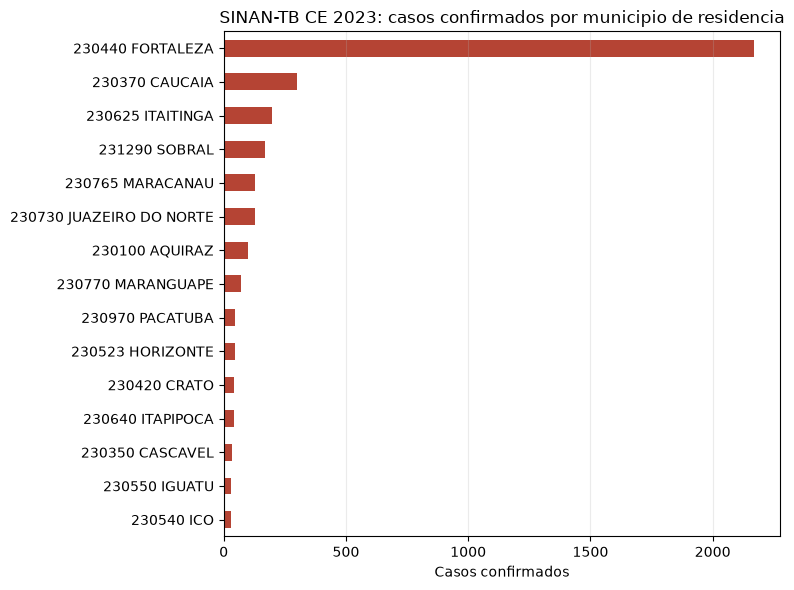

In [12]:
# Exemplo de grafico com a amostra agregada do TabNet.
municipal_cases = tabnet_samples.get("cases_by_residence_municipality")
if municipal_cases is not None and "Casos confirmados" in municipal_cases.columns:
    plot_df = municipal_cases[municipal_cases.iloc[:, 0] != "Total"].copy()
    plot_df = plot_df.sort_values("Casos confirmados", ascending=False).head(15)

    ax = plot_df.sort_values("Casos confirmados").plot.barh(
        x=plot_df.columns[0],
        y="Casos confirmados",
        figsize=(8, 6),
        legend=False,
        color="#B54434",
    )
    ax.set_title("SINAN-TB CE 2023: casos confirmados por municipio de residencia")
    ax.set_xlabel("Casos confirmados")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()



## Entrada opcional para CSVs DATASUS/CNES/SINAN/SIM

Coloque arquivos exportados manualmente ou convertidos de DBC/DBF em `data/raw/manual/`.

Nomes esperados por este notebook:

- `sinan_tb_tabnet.csv`
- `sim_tb_tabnet.csv`
- `cnes_estabelecimentos.csv`
- `sih_tb_tabnet.csv`
- `sisab_aps.csv`

Links uteis para exportacao manual:

- SINAN-TB Ceara TabNet: <http://tabnet.datasus.gov.br/cgi/deftohtm.exe?sinannet/cnv/tubercce.def>
- DATASUS transferencia de arquivos: <https://datasus.saude.gov.br/transferencia-de-arquivos/>

A primeira versao do projeto deve aceitar CSVs manuais antes de automatizar POSTs do TabNet ou conversao de DBC.




In [13]:
def read_optional_csv(file_name: str) -> pd.DataFrame | None:
    path = MANUAL_DIR / file_name
    if not path.exists():
        print(f"not found: {path.relative_to(PROJECT_ROOT)}")
        return None

    for encoding in ["utf-8", "latin1"]:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=encoding)
            df.columns = [str(col).strip() for col in df.columns]
            print(f"loaded: {path.relative_to(PROJECT_ROOT)} rows={len(df):,} columns={len(df.columns)}")
            return df
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("unknown", b"", 0, 1, f"could not decode {path}")

sinan_tb = read_optional_csv("sinan_tb_tabnet.csv")
sim_tb = read_optional_csv("sim_tb_tabnet.csv")
cnes = read_optional_csv("cnes_estabelecimentos.csv")
sih_tb = read_optional_csv("sih_tb_tabnet.csv")
sisab_aps = read_optional_csv("sisab_aps.csv")




not found: data/raw/manual/sinan_tb_tabnet.csv
not found: data/raw/manual/sim_tb_tabnet.csv
not found: data/raw/manual/cnes_estabelecimentos.csv
not found: data/raw/manual/sih_tb_tabnet.csv
not found: data/raw/manual/sisab_aps.csv


In [14]:
# Visualizacao generica para qualquer CSV opcional carregado.
# Se o arquivo tiver colunas numericas, mostra as maiores somas por coluna.
for name, df in {
    "sinan_tb": sinan_tb,
    "sim_tb": sim_tb,
    "cnes": cnes,
    "sih_tb": sih_tb,
    "sisab_aps": sisab_aps,
}.items():
    if df is None:
        continue
    display(df.head())
    numeric = df.select_dtypes(include="number")
    if not numeric.empty:
        totals = numeric.sum(numeric_only=True).sort_values(ascending=False).head(10)
        ax = totals.sort_values().plot.barh(figsize=(8, 4), color="#7353BA")
        ax.set_title(f"{name}: maiores somas numericas")
        ax.set_xlabel("soma")
        plt.tight_layout()
        plt.show()




## Estrutura analitica esperada

Para o MVP 1, a ingestao real deve convergir para tabelas canonicas. Esta celula cria exemplos vazios com os campos esperados. Use isso como contrato para transformar CSVs brutos em dados consumidos pelo indicador engine.




In [15]:
canonical_tables = {
    "Territory": [
        "territory_id",
        "territory_name",
        "territory_level",
        "parent_territory_id",
        "ibge_code",
    ],
    "PopulationDenominator": [
        "territory_id",
        "year",
        "sex",
        "age_group",
        "population",
        "source_id",
        "import_run_id",
    ],
    "CaseAggregate": [
        "territory_id",
        "period",
        "territory_role",
        "case_form",
        "entry_type",
        "sex",
        "age_group",
        "race_color",
        "education_level",
        "vulnerability_group",
        "lab_confirmation_status",
        "hiv_test_status",
        "hiv_result",
        "contact_investigation_status",
        "tdo_status",
        "closure_status",
        "count",
        "source_id",
        "import_run_id",
    ],
    "MortalityAggregate": [
        "territory_id",
        "period",
        "cid10_group",
        "sex",
        "age_group",
        "race_color",
        "death_count",
        "source_id",
        "import_run_id",
    ],
    "Facility": [
        "facility_id",
        "cnes_id",
        "facility_name",
        "territory_id",
        "facility_type",
        "management_type",
        "has_sus_service",
        "source_id",
        "import_run_id",
    ],
}

for table, columns in canonical_tables.items():
    print(f"{table}: {', '.join(columns)}")




Territory: territory_id, territory_name, territory_level, parent_territory_id, ibge_code
PopulationDenominator: territory_id, year, sex, age_group, population, source_id, import_run_id
CaseAggregate: territory_id, period, territory_role, case_form, entry_type, sex, age_group, race_color, education_level, vulnerability_group, lab_confirmation_status, hiv_test_status, hiv_result, contact_investigation_status, tdo_status, closure_status, count, source_id, import_run_id
MortalityAggregate: territory_id, period, cid10_group, sex, age_group, race_color, death_count, source_id, import_run_id
Facility: facility_id, cnes_id, facility_name, territory_id, facility_type, management_type, has_sus_service, source_id, import_run_id


## Primeiro indicador calculavel quando houver CSV de casos

Quando `data/raw/manual/tb_indicadores_municipais.csv` existir com as colunas abaixo, o notebook calcula incidencia e mortalidade rapidamente:

- `municipality_id`
- `municipality_name`
- `year`
- `new_cases`
- `deaths`
- `population`

Esse arquivo pode ser montado manualmente a partir do TabNet enquanto a ingestao automatica ainda nao existe.




In [16]:
indicator_input = read_optional_csv("tb_indicadores_municipais.csv")
if indicator_input is not None:
    required = {"municipality_id", "municipality_name", "year", "new_cases", "deaths", "population"}
    missing = required - set(indicator_input.columns)
    if missing:
        raise ValueError(f"missing columns in tb_indicadores_municipais.csv: {sorted(missing)}")

    indicators = indicator_input.copy()
    indicators["tb_incidence_per_100k"] = indicators["new_cases"] / indicators["population"] * 100_000
    indicators["tb_mortality_per_100k"] = indicators["deaths"] / indicators["population"] * 100_000
    display(indicators.sort_values("tb_incidence_per_100k", ascending=False).head(20))

    ax = indicators.sort_values("tb_incidence_per_100k").plot.barh(
        x="municipality_name",
        y="tb_incidence_per_100k",
        figsize=(8, 6),
        color="#B54434",
        legend=False,
    )
    ax.set_title("Incidencia de TB por 100 mil habitantes")
    ax.set_xlabel("casos novos / 100 mil hab.")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()




not found: data/raw/manual/tb_indicadores_municipais.csv


## Proximos passos

1. Exportar uma tabela pequena do TabNet SINAN-TB para `data/raw/manual/sinan_tb_tabnet.csv`.
2. Exportar ou montar `tb_indicadores_municipais.csv` para validar incidencia e mortalidade contra o Boletim 2026.
3. Decidir se a ingestao DATASUS inicial sera por CSV exportado do TabNet ou por arquivos DBC convertidos.
4. Criar transformadores para preencher `CaseAggregate`, `MortalityAggregate`, `Facility` e `IndicatorValue`.

